In [1]:
pip install atproto numpy pandas matplotlib networkx scipy nltk tabulate emoji scikit-learn transformers torch pyldavis wordcloud jupyter ipywidgets


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Social Media and Network Analytics - Assignment 2
## Our Question:
- What are peoples limits to Ai generated content in video games?

## Files and Directories:
- Our dataset folder contains all of the json data we have worked with and graphml files we have generated
- Our graphs folder the graphs we have generated for networks and communities using networkx or gephi

## Team Members:
- Mitchell Long: S4007880
- Jimmy Vu: S4006701
- Khang Nguyen: S4005711

In [2]:
from atproto import Client
from account import getAccount
import emoji
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
import json
import re
import pandas as pd
from collections import Counter
import tabulate
import matplotlib.pyplot as plt
from transformers import pipeline
import numpy as np
import math

import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /home/tmd12/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/tmd12/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/tmd12/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/tmd12/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/tmd12/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [3]:
datasetPath = "./dataset/"
searchQueries = [
    "Artificial Intelligence, AI, games", 
    "Artificial Intelligence, AI, Larian", 
    "Artificial Intelligence, AI, Expedition 33", 
    "Artificial Intelligence, AI, Battlefield 6", 
    "Artificial Intelligence, AI, Shift Up",
    "Generative AI, Games",
    "Generative AI, Good",
    "Generative AI, Bad",
    "AI Slop, Games"
    ]

# Currently set as False to not override json data
getData = True

### Data Collection and Formatting

In [ ]:
# Running this block will prompt user input for username and password
# Keeping this separate allows us to use client apis later in the notebook 
# without needing to recollect data again
username, password = getAccount()
client = Client()
client.login(username, password)

In [5]:
# Run a search query and collect postst
# getData will need to be set to True earlier for us to run this section 
# getData currently set to false to not override our data json file
if (getData):
        
    structured_posts = []
    for q in searchQueries:
        search_results = client.app.bsky.feed.search_posts({"q": q, "limit": 100})
        display(search_results)

        # Iterate through each collected post and its replies
        for post in search_results.posts:

            # Print posts for output proof
            name = post.author.display_name

            if name is None:
                name = post.author.handle
                
            print(name + ": ")
            print(post.record.text)
            print('\n')

            # Fetch thread for this post using the uri
            thread = client.app.bsky.feed.get_post_thread({
                "uri": post.uri
            })

            replies_data = []

            replies = getattr(thread.thread, "replies", [])

            # Create JSON structure for each reply
            for reply in replies:
                if hasattr(reply, "post"):

                    reply_post = reply.post

                    replies_data.append({
                        "reply_id": reply_post.uri,
                        "text": reply_post.record.text,
                        "created_at": getattr(reply_post.record, "created_at", None),

                        "author": {
                            "display_name": reply_post.author.display_name,
                            "handle": reply_post.author.handle
                        },

                        "engagement": {
                            "likes": reply_post.like_count,
                            "replies": reply_post.reply_count,
                            "reposts": reply_post.repost_count
                        }
                    })

            # Create JSON structure for original post and append comments
            structured_post = {
                "post_id": post.uri,
                "text": post.record.text,
                "created_at": getattr(post.record, "created_at", None),

                "author": {
                    "display_name": post.author.display_name,
                    "handle": post.author.handle,
                    "did": post.author.did
                },

                "engagement": {
                    "likes": post.like_count,
                    "reposts": post.repost_count,
                    "replies": post.reply_count,
                    "quotes": post.quote_count
                },

                "metadata": {
                    "lang": getattr(post.record, "langs", [])
                },

                # Comments appended here
                "comments": replies_data
            }

            # Add posts to one object
            structured_posts.append(structured_post)

        # Create and save data to JSON file
        data = {'posts': structured_posts}

    with open(datasetPath + "bluesky_posts.json", "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4, ensure_ascii=False)

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:pnx2fjuannbdpy3337ggthpp', handle='peark.es', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='all', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:pnx2fjuannbdpy3337ggthpp/bafkreidzvakiwbiqaj324i3grmh3efa6uq7jk3kudi7ill3j362exktwbe', created_at='2023-04-27T22:11:20.453Z', debug=None, display_name='George Pearkes', labels=[], pronouns=None, status=None, verification=VerificationState(trusted_verifier_status='none', verifications=[VerificationView(created_at='2026-01-09T14:55:08.805Z', is_valid=True, issuer='did:plc:z72i7hdynmk6r22z27h6tvur', uri='at://did:plc:z72i7hdynmk6r2

George Pearkes: 
immediately he is playing games with framing. It's not mysterious or sinister at all, they leaked because they're being circulated to a larger circle of people as part of the fundraising round. This is not skeptical or objective reporting, just pure spin.


Nick V (get Chico's Rebound!): 
Something I've been meaning to do for a while, have put up a couple statements of ethics on @daikon.games website. This includes my stance on AI in games (or my stance against it rather!)

I like the idea of having it written out somewhere 
#indiegames #gamedev

daikon.games/ethics.html


Dsards_noodle: 
 )

2)pasarkerkap= pay sar(Key) rk(kk dd) er = Kap! Cap; 
Kerek , eki, ap= 42,  Sardidi!
Sardidi!

3) goenoengsailin
= Go no oen(games  )English en no oen games (Queen)
99 no, Gani no ! Gay no oen(games) ex, negs Ex, anger, is business Ai(artificial intelligence) lin! Anger!


Omelette_AsiatiK ★: 
 "Artificial intelligence is structurally integrated into the organization and experienc

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:3ajpvlmcknvvbenxwijizg5p', handle='yarns-and-d20s.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='mutuals', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='all', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:3ajpvlmcknvvbenxwijizg5p/bafkreiebhjj3ewqzvfiid5wc6gg7ppsg2fvmjppfhvpjewind5ukzfyhw4', created_at='2023-06-26T17:32:23.475Z', debug=None, display_name='JT (paladin enthusiast)', labels=[], pronouns=None, status=None, verification=None, viewer=ViewerState(activity_subscription=None, blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by

JT (paladin enthusiast): 
Because the Larian & generative AI thing is going around, I want to correct something I personally said and misunderstood regarding *Expedition 33* and AI: 

english.elpais.com/culture/2025...

&

www.gamepressure.com/newsroom/a-f...

(1/7)


: 
#Hotnews #News #KingdomCome Larian: An AI Hysteria Has Emerged, Says the Creative Director of Kingdom Come: Deliverance!: Larian’s admission regarding the use of artificial intelligence has sparked a major online debate, one that Daniel Vávra has now addressed in blunt terms.   Larian Studios has…


Abby Pollak 🍉: 
Hey look, three fun new images of my Dungeons and Dragons character generated by my OWN HUMAN FUCKING HANDS, LARIAN.




Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:3ajpvlmcknvvbenxwijizg5p', handle='yarns-and-d20s.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='mutuals', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='all', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:3ajpvlmcknvvbenxwijizg5p/bafkreiebhjj3ewqzvfiid5wc6gg7ppsg2fvmjppfhvpjewind5ukzfyhw4', created_at='2023-06-26T17:32:23.475Z', debug=None, display_name='JT (paladin enthusiast)', labels=[], pronouns=None, status=None, verification=None, viewer=ViewerState(activity_subscription=None, blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by

...

Kevin Veale 😷 (Toitū Te Tiriti): 
Pillowfort's a good long-form option some chosters are trying? 

It has good anti-harassment tools, banned generative AI material + terfs + nazis, and the devs prioritise community safety over making money.

If you ever want to check it out, I can share some resources for making that easy?


🔞Ikari Wolf🔞 🔜 ASC, Furality: 
JFC. Generative AI is now being used to scam people. And for huge amounts. If a classic car is too good to be true, it's a scam. Never buy anything unseen.

People have lost tens of thousands of dollars because of this emerging scam.


Sparkel Dog: 
entered my username on a website to see who has me blocked out of pure curiosity, and apparently im on some block list of “ai haters”…. GOOD LMAO. I do hate generative ai and everything it stands for and how its destroying the environment and our minds. You should block me if you use that shit lmao


Neon Innovation Lab: 
"NVIDIA just dropped the RTX 5000 series with a mind-blowing 500 TFL

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:5vmvghvinjsrqytfutjbewrp', handle='clubzenny.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=ProfileAssociatedChat(allow_incoming='all', py_type='app.bsky.actor.defs#profileAssociatedChat'), feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:5vmvghvinjsrqytfutjbewrp/bafkreiggahsbpjosul3juy6e77yu44f5lp4fac2wmdjioiyb73iyxihqq4', created_at='2024-02-06T20:04:04.051Z', debug=None, display_name='Zenny', labels=[], pronouns=None, status=None, verification=None, viewer=ViewerState(activity_subscription=None, blocked_by=False, blocking=None, blocking_by_list=None, followed_by=None, following=None, known_followers=None, muted=False, muted_by_list=None, py_type='

Zenny: 
Yeah I don't give a shit who they are, if I see someone 'just' using AI for something minor it's still bad. I literally know people who have lost jobs because of generative AI bullshit


Alex Strook 🐭⚡️SQUEAKROSS: 
the real artistry is making infographics that bad 😭 it's pretty telling about how these people see art 

generative ai only purpose is grift and misinformation exhibit #549432


Orlando B: 
www.livescience.com/technology/a... Generative AI is destroying the baseline assumption that photographs bear some causal connection to reality. That's bad news for democracy.


LittleViking: 
I am so tierd of having to keep arguing with people why generative AI is bad only for them to draw stupid strawman arguments like

" Well if you care about the environment why are you playing WoW ?? That use energy and electricity too! Hypocrite!"


Miko♪: 
"But I use it as a last resort" I don't care. If you USED it but eventually realized how awful it is and also are against it now, then I

Response(posts=[PostView(author=ProfileViewBasic(did='did:plc:nnisa44lmte6rxxmf5f4ccba', handle='eriugam.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=None, feedgens=None, labeler=None, lists=None, starter_packs=None, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:nnisa44lmte6rxxmf5f4ccba/bafkreihq7vlvbhkv3xybpxttsphg53rglro3n5jqdw5nufmr3rrf57cxym', created_at='2024-06-15T00:03:18.440Z', debug=None, display_name='Eri', labels=[Label(cts='2024-06-15T00:03:20.055Z', src='did:plc:nnisa44lmte6rxxmf5f4ccba', uri='at://did:plc:nnisa44lmte6rxxmf5f4ccba/app.bsky.actor.profile/self', val='!no-unauthenticated', cid='bafyreieyytknbiywn6djdih4czhto6xkw67k5lghaut7e7boerpgqqpy4y', exp=None, neg=None, sig=None, ver=None, py_type='com.atproto.label.defs#label')], pronouns=None, statu

Eri: 
I criticise games now, before the inevitable AI slop starts creeping into them.

Humans make equally as bad digital media.


Another Terrible Idea: 
Level One is gets a ton of props as far as barcodes in town go just for actually caring about games enough to show Combo Breaker on one of their TVs. No others bothered to do that over the years. 

Thumbs down for their AI slop advertising, though. 

My MMPR sticker and buddies shown here!


🪄 Naomi "Note Worthy" Slover: 
This sounds kinda dope, if they can make it a successful technology over time.

Before GenAI slop showed up everywhere, we HAD AI engines in our video games and thought little of it.


restlessBear: 
I have a good sized library of games, I don't need more. I'm not giving you money for a game unless you make the effort to say you're rejecting the use of theft and plagiarism ai slop generators.


restlessBear: 
I had five games in my Steam cart from my wishlist. After review, I'm down to one. The other four either a) 

# Part 1 Analysis - Network Connections
Resort the json by likes so we can collect network of the most influential posts

In [6]:
with open(datasetPath + "bluesky_posts.json", "r") as file:
    data = json.load(file)

data["posts"].sort(
    key=lambda post: post["engagement"]["likes"],
    reverse=True
)

with open(datasetPath + "sorted_bluesky_posts.json", "w", encoding="utf-8") as file:
    json.dump(data, file, indent=4, ensure_ascii=False)

Time to collect followers and following from the top most liked posts

In [7]:
# HEADS UP THIS PART TAKES A LONG TIME AS IT IS RUNNING MANY API CALLS TO COLLECT COUNTS
# Run the sorting cell before running this cell
with open(datasetPath + "sorted_bluesky_posts.json", "r") as file:
    data = json.load(file)

posts = data["posts"]

# Here sets how many posts (Currently at top 50 posts)
top_posts = posts[:50]

results = []

for post in top_posts:
    # We will use the did to differenciate from accounts as it is unique
    did = post["author"]["did"]

    handle = post["author"]["handle"]

    print(f"Fetching: {handle}")

    # We collect the handles for better displaying once we put it in graphs
    try:
        # Collecting counts of followers and following
        profile = client.app.bsky.actor.get_profile({
            "actor": did
        })

        print("Followers:", profile.followers_count)
        print("Following:", profile.follows_count)
        
        # followers
        followers_response = client.app.bsky.graph.get_followers({
            "actor": did,
            "limit": 100
        })

        # follows
        follows_response = client.app.bsky.graph.get_follows({
            "actor": did,
            "limit": 100
        })

        # Loop through each follower and following to get their counts as well
        followers = []

        for user in followers_response.followers:
            profile = client.app.bsky.actor.get_profile({
                "actor": user.did
            })

            print("Followers:", profile.followers_count)
            followers.append({"user": user.handle, "followers_count": profile.followers_count})

        following = []

        for user in follows_response.follows:
            profile = client.app.bsky.actor.get_profile({
                "actor": user.did
            })

            print("Followers:", profile.followers_count)
            following.append({"user": user.handle, "followers_count": profile.followers_count})

        results.append({
            "handle": handle,
            "did": did,
            "followers_count": profile.followers_count,
            "following_count": profile.follows_count,
            "followers": followers,
            "following": following
        })

    except Exception as e:
        print(f"Error with {handle}: {e}")

# ---------------------------------
# save output
# ---------------------------------
with open(datasetPath + "user_follows.json", "w", encoding="utf-8") as file:
    json.dump(results, file, indent=2, ensure_ascii=False)

Fetching: leftistlawyer.com
Followers: 64543
Following: 5323
Followers: 698
Followers: 245
Followers: 191
Followers: 2
Followers: 11351
Followers: 1125
Followers: 45
Followers: 173
Followers: 252
Followers: 19
Followers: 496
Followers: 6765
Followers: 364
Followers: 14714
Followers: 32
Followers: 3663
Followers: 4
Followers: 63
Followers: 168
Followers: 1034
Followers: 2031
Followers: 926
Followers: 275
Followers: 982
Followers: 154
Followers: 770
Followers: 2776
Followers: 111
Followers: 2665
Followers: 168
Followers: 3
Followers: 3752
Followers: 68
Followers: 356
Followers: 3094
Followers: 4007
Followers: 211
Followers: 0
Followers: 137
Followers: 17
Followers: 218
Followers: 308
Followers: 447
Followers: 118
Followers: 262
Followers: 228
Followers: 365
Followers: 246
Followers: 241
Followers: 1138
Followers: 163
Followers: 186
Followers: 407
Followers: 255
Followers: 180
Followers: 1295
Followers: 112
Followers: 48
Followers: 94
Followers: 259
Followers: 1035
Followers: 232
Follower

### Visualising Network Communities
Workshop code taken from Week7 as a basis:


In [8]:
import networkx as nx

# Lets display the network of the most liked post author
with open(datasetPath + "user_follows.json", "r", encoding="utf-8") as file:
    data = json.load(file)

egoGraph = nx.DiGraph()

for egoUser in data:
    egoName = egoUser["handle"]
    egoGraph.add_node(egoName, followers=egoUser["followers_count"])

    # followers we have collected earlier
    # we point creator towards follower instead to show influence and for independent cascade
    for follower in egoUser["followers"]:
            # add follower to graph
            # first add node then add the edge
            egoGraph.add_node(follower["user"], followers=follower["followers_count"])

            egoGraph.add_edge(egoName, follower["user"])

    for following in egoUser["following"]:
        # add follower to graph
        # first add node then add the edge
        egoGraph.add_node(following["user"], followers=following["followers_count"])

        egoGraph.add_edge(following["user"], egoName)

Some Network Analysis related to an ego

In [9]:
# Save graph to file with directions
graphFile=datasetPath + 'communityNetwork.graphml'

with open(datasetPath + "user_follows.json", "r", encoding="utf-8") as file:
    data = json.load(file)
    
first_nodeUser = data[0]["handle"]

# Lets print out the network of the first user to demonstrate the connections created
inDeg = egoGraph.in_degree(first_nodeUser)
outDeg = egoGraph.out_degree(first_nodeUser)

print('in degree of ego = {}'.format(inDeg))
print('out degree of ego = {}'.format(outDeg))

lInNeighbours = [sNeigh for sNeigh in egoGraph.predecessors(first_nodeUser)]
lOutNeighbours = [sNeigh for sNeigh in egoGraph.successors(first_nodeUser)]

# This essentially goes through the in neighbours list and outputs them one by one
print('in neighbours of ego = {', end='')
print(*lInNeighbours, sep=', ', end='')
print('}')

print('out neighbours of ego = {', end='')
print(*lOutNeighbours, sep=', ', end='')
print('}')

# this code outputs the graph as graphml format, which can be then visualised by an external program
with open(graphFile, 'wb') as fOut:
    nx.write_graphml(egoGraph, fOut)

in degree of ego = 95
out degree of ego = 86
in neighbours of ego = {thealmostbear.bsky.social, baltlegal.bsky.social, blackapostate.blacksky.app, deecherrywriter.bsky.social, notyournegro.blacksky.app, adastragames.com, solitarywatch.bsky.social, empressedyn.bsky.social, wtfis2bdone.bsky.social, gaycannibalism.bsky.social, thesicktimes.org, jenlucpiquant.bsky.social, atrupar.com, layla.btslinger.ie, proptermalone.bsky.social, marteki.bsky.social, forrestvalkai.bsky.social, mattdillahunty.bsky.social, josierosec.bsky.social, francesdanger.bsky.social, izzos.net, cmcaplanwrites.bsky.social, poppyhaze.bsky.social, deathpanel.bsky.social, harshawalia.bsky.social, robinkelly.house.gov, utopia-defer.red, skepchick.org, theardenhart.bsky.social, ryanclancywi.bsky.social, jovanbradley.bsky.social, wonkicorn.bsky.social, vincent.northsky.social, bogbody.kindboys.online, buppy.kindboys.online, rafiamahli.com, punkrockscience.bsky.social, gaius.bsky.social, allegrak.bsky.social, itsafronomics.bl

# Visualising the Ego Net
We show off a multi ego network to display network following and followers

More code from workshop 7 used as a basis:

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# We have set up a multi ego network of 50 users
lInNeighbours = set()
lOutNeighbours = set()

node_colors = []
node_sizes = []

egoUsers = {
    user["handle"]
    for user in data
}

for ego in egoUsers:
    # Following
    lInNeighbours.update(
        egoGraph.predecessors(ego)
    )

    # Followers
    lOutNeighbours.update(
        egoGraph.successors(ego)
    )

for n in egoGraph.nodes():
    if n in egoUsers:
        node_colors.append("gold")
        node_sizes.append(3000)
    else:
        in_only = (n in lInNeighbours) and (n not in lOutNeighbours)
        out_only = (n in lOutNeighbours) and (n not in lInNeighbours)
        both = (n in lInNeighbours) and (n in lOutNeighbours)

        if both:
            node_colors.append("mediumpurple")
        elif in_only:
            node_colors.append("skyblue")
        elif out_only:
            node_colors.append("lightcoral")
        else:
            node_colors.append("lightgray")

        # We influence node size by follower count
        followers = egoGraph.nodes[n].get("followers", 0)
        node_sizes.append(100 + 0.05 * followers)

plt.figure(figsize=(140, 110))
pos = nx.spring_layout(egoGraph, seed=42, k=1.2)

nx.draw_networkx_nodes(
    egoGraph,
    pos,
    node_color=node_colors,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    egoGraph,
    pos,
    arrows=True
)

nx.draw_networkx_labels(
    egoGraph,
    pos,
    font_size=25
)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='ego',
           markerfacecolor='gold', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='in-only',
           markerfacecolor='skyblue', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='out-only',
           markerfacecolor='lightcoral', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='both',
           markerfacecolor='mediumpurple', markersize=12)
]

plt.legend(handles=legend_elements, loc='best')
plt.axis("off")
plt.show()

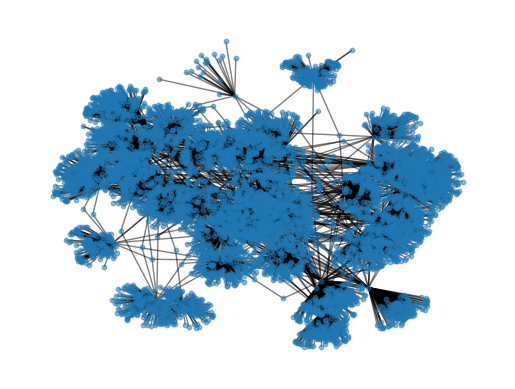

In [ ]:
#
# Draw graph
#

from matplotlib.patches import ArrowStyle

# use networkx to draw
# opt for a smaller node size than the default 300 as it is too much and also removal of with labels taking too much space
nx.draw_networkx(egoGraph, pos=nx.spring_layout(egoGraph, seed=42), arrows=False, with_labels=False, node_size=10, alpha=0.5)
plt.axis('off')
plt.show()

## Reply graph contruction
Week 9 code as basis:

In [14]:
import pandas as pd
import networkx as nx
import json 

#load data

with open(datasetPath + "sorted_bluesky_posts.json" , "r") as Jfile:
    data = json.load(Jfile)

posts = data["posts"]

rows = []

for post in posts:
    post_id = post["post_id"]
    author_handle = post["author"]["handle"]

    for com in post.get("comments", []):
        rows.append({
            "comment_id": com["reply_id"],
            "author": com["author"]["handle"],
            "parent_id": post_id,
            "thread_id": post_id,
            "is_author": False
        })

    rows.append({
    
        "comment_id": post_id,
        "author": author_handle,
        "parent_id": post_id,
        "thread_id": post_id,
        "is_author": True
    }
    )

df = pd.DataFrame(rows)
df = df.dropna(subset=["author", "comment_id", "parent_id", "thread_id"])
df = df.astype({
    "author":str,
    "comment_id": str,
    "parent_id": str,
    "thread_id" : str
})

num_threads = 50

selected_threads = df["thread_id"].unique()[:num_threads]
df = df[df["thread_id"].isin(selected_threads)]

print(df.shape)
print("Num of threads: ", df["thread_id"].nunique())


(393, 5)
Num of threads:  50


In [15]:
# Only comments
id2author = dict(zip(df[df["is_author"] == False]["comment_id"],
                     df[df["is_author"] == False]["author"]))

# Only post authors
thread2author = dict(
    df[df["is_author"] == True]
    .groupby("thread_id")["author"]
    .first()
)

# Add post authors into id2author for edge lookup
for post in posts:
    id2author[post["post_id"]] = post["author"]["handle"]

sub_counts = pd.Series(thread2author).value_counts().to_dict()

In [16]:
# creating the graph
replyGraph = nx.DiGraph()

for user in df["author"].unique():
    replyGraph.add_node(
        user,
        subNum=int(sub_counts.get(user, 0))
    )

for _, row in df.iterrows():
    user = row["author"]        # fixed: removed trailing comma
    parent_id = row["parent_id"]  # fixed: removed trailing comma
    thread_id = row["thread_id"]

    if parent_id == thread_id:
        parent_user = thread2author.get(thread_id)
    else:
        parent_user = id2author.get(parent_id)

    if parent_user and parent_user != user:
        if replyGraph.has_edge(user, parent_user):
            replyGraph[user][parent_user]["replyNum"] += 1
        else:
            replyGraph.add_edge(
                user,
                parent_user,
                replyNum=1
            )

print("Nodes:", replyGraph.number_of_nodes())
print("Edges:", replyGraph.number_of_edges())
nx.write_graphml(replyGraph, datasetPath + "communityReplyGraph.graphml")

Nodes: 339
Edges: 296


## SNA Measure

We run centrality and SNA Measure calculations using the reply graph we have just generated and anything else afterwards for part 1 

Code Taken from workshop 8 as a basis:

In [17]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Computing centrality

In [26]:
sFileName = datasetPath + "communityReplyGraph.graphml"

# read it back in to demonstrate it works
networkGraph = nx.readwrite.read_graphml(sFileName)


# computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(networkGraph)


# Compute eigenvetor and katz centrality
# Could not run EigenVector due to convergence so we had to put a tolerance and increase max iterations default 100
lEigenVectorCentrality = nx.eigenvector_centrality(
    networkGraph,
    max_iter=500,
    tol=1e-06
)

lKatzCentrality = nx.katz_centrality(networkGraph)


Plot the histograms of all degree, eigenvector and katz centrality

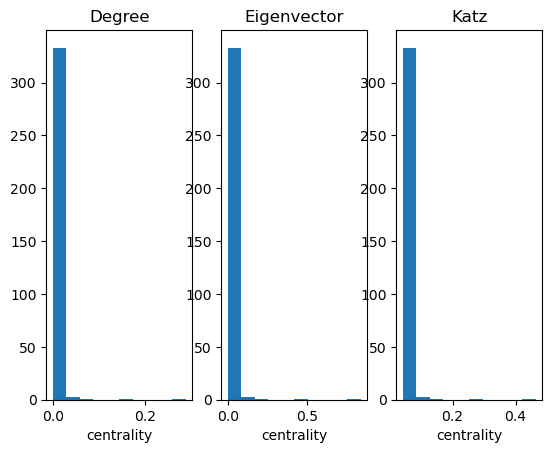

In [27]:
# plot histograms
# degree centrality
plt.subplot(1,3,1)
plt.hist(list(lDegCentrality.values()))
plt.title('Degree')
plt.xlabel('centrality')

# eigenvector centrality
plt.subplot(1, 3, 2)
plt.hist(list(lEigenVectorCentrality.values()))
plt.title('Eigenvector')
plt.xlabel('centrality')
# katz centrality
plt.subplot(1, 3, 3)
plt.hist(list(lKatzCentrality.values()))
plt.title('Katz')
plt.xlabel('centrality')

plt.show()

The following code computes the SNA statistics/measures to do with centrality, clustering coefficient, connected components and bridges.

In [28]:
# Update the node attributes with centrality

# eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    networkGraph.nodes[nodeId]['eigen'] = float(cent)

# katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    networkGraph.nodes[nodeId]['katz'] = float(cent)

# Split sFileName to created modified file
sFileNameSplit = sFileName.split('.', 2)
sFileNameSplit = '.'.join(sFileNameSplit[:2])

# Write out graph to new file
nx.readwrite.write_graphml(networkGraph, sFileNameSplit + "_SNA.graphml", infer_numeric_types=True)


# Compute the other SNA measures specified in the lab

# compute clustering
# the networkx code is within format(...)
print('Global clustering coefficient/transitivit = {}'.format(nx.transitivity(networkGraph)))


# compute components
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(networkGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(networkGraph)))


# compute bridges
print(list(nx.bridges(networkGraph.to_undirected())))


Global clustering coefficient/transitivit = 0
number of strongly connected components = 339
number of weakly connected components = 43
[('suelou9-25.bsky.social', 'leftistlawyer.com'), ('basilmai.bsky.social', 'leftistlawyer.com'), ('ugarles.bsky.social', 'leftistlawyer.com'), ('jamesdavismakes.com', 'leftistlawyer.com'), ('shelleybwoke.bsky.social', 'leftistlawyer.com'), ('nigeloverstreet.bsky.social', 'leftistlawyer.com'), ('shoshiroll.bsky.social', 'leftistlawyer.com'), ('crankypacifist.bsky.social', 'leftistlawyer.com'), ('queen-calamity.bsky.social', 'leftistlawyer.com'), ('noctifloraa.bsky.social', 'leftistlawyer.com'), ('gtmac.bsky.social', 'leftistlawyer.com'), ('cv-danes.com', 'leftistlawyer.com'), ('matthewdownhour.bsky.social', 'leftistlawyer.com'), ('cacaobyproduct.bsky.social', 'leftistlawyer.com'), ('toonspin.nl', 'leftistlawyer.com'), ('toonspin.nl', 'clapifyoulikeme.favrd.social'), ('thecrimsontint.com', 'leftistlawyer.com'), ('crosis101.bsky.social', 'leftistlawyer.com

## Community Detection
Using our modified Reply Graph

Code taken from week 9 as a basis

In [32]:
import networkx as nx
# python-louvain
import community
import random
import csv

import matplotlib.pyplot as plt

# filename of graph to use 
sFileName = datasetPath + "communityReplyGraph.graphml"

In [33]:
def dictToSetFormat(dComments, maxCommentNum):
    lSets = [set() for x in range(maxCommentNum)]
    for (name, clusId) in dComments.items():
        lSets[clusId].add(name)
    return lSets


In [34]:
replyGraph = nx.read_graphml(sFileName)

k = 4
lCpmComms = list(nx.algorithms.community.k_clique_communities(nx.to_undirected(replyGraph), k))
print(lCpmComms)

dLouvainComms = community.best_partition(nx.to_undirected(replyGraph))
print("Louvain communities found: ", max(dLouvainComms.values()) + 1)

louvainCommNum = max([y for (x,y) in dLouvainComms.items()]) + 1
lLouvainComms = dictToSetFormat(dLouvainComms, louvainCommNum)

for clusId, lComms in enumerate(lCpmComms):
    for nodeId in lComms:
        replyGraph.nodes[nodeId]['cpmClusId'] = clusId

for clusId, lComms in enumerate(lLouvainComms):
    for nodeId in lComms:
        replyGraph.nodes[nodeId]['louvain'] = clusId



print("Saved to testGraph_communities.graphml")

nx.readwrite.write_graphml(replyGraph, sFileName + "_CPMLOUVAIN", infer_numeric_types=True)


[]
Louvain communities found:  45
Saved to testGraph_communities.graphml


### Random Cascade
Week 10 workshop code as basis:

In [35]:
import time
import random
import numpy as np
import networkx as nx

This function performs the independent cascade.

In [36]:
def independentCascade(graph, trialNum, lSeed, activationProb):
    """
    Performs independent cascade over the input graph.  Results are stored in two output
    lists.

    @param graph: Input graph to perform cascade over.
    @param trialNum: The number of runs/trials to run.  The results are averaged over the
                    the trials/runs.
    @param lSeed: List of initial nodes to seed.  Range from 0 to number of nodes -1.
    @param activationProb: Activation probability on each edge.  All edges have the same
                    activation probability.

    @return: Two lists, lAvgActivationsPerNode and lAvgActivationsPerIteration.
            lAvgActivationsPerNode is a list with the size same as the number of nodes in
            the graph.  Each index of the list (starting with zero) corresponds directly
            to the associated node, and each entry represents the average number of activations
            over the trials/runs, and should lie in [0,1] range.
            lAvgActivationsPerIteration is a list with the size same as the number of trials/runs.
            Each index of the list corresponds to a trial/run, and each entry is the
            total number of active nodes in that trial/run.
    """

    # generate initial lists/vectors for the two output lists
    # This is set since we do not use integer ids for nodes we use the string names instead
    lAvgActivationsPerNode = {
    node: 0
    for node in graph.nodes()
    }
    lAvgActivationsPerIteration = []

    print('starting cascade run')
    # loop through the runs/trials
    for i in range(trialNum):
        print('Trial/run no. {}'.format(i))
        
        # list of active nodes
        setActive = set(lSeed)
        setLastActive = set(lSeed)
        setNewActive = set()
        # we keep looping until no more new activations
        while len(setLastActive) > 0:
            # for each active node, we try to influence its (unactived neighbours)
            for currNode in setLastActive:
                # check each neighbour
                for neighbour in graph.neighbors(currNode):
                    # we only want non-active neighbours
                    if neighbour not in setActive and neighbour not in setNewActive:
                        if random.random() < activationProb:
                            setNewActive.add(neighbour)

            # update last active
            setLastActive = setNewActive
            # extend active set
            setActive.update(setNewActive)
            # reset new active
            setNewActive = set()

        # update the output lists
        for x in setActive:
            lAvgActivationsPerNode[x] += 1

        # update with total number of activations
        lAvgActivationsPerIteration.append(len(setActive))

    # we average each entry in lAvgActivationsPerNode by number of runs/trials
    return {
        node: count / trialNum
        for node, count in lAvgActivationsPerNode.items()
    }, lAvgActivationsPerIteration


Independent cascade calculation on reply graph

In [37]:
# graph fileName
inputFile = "communityReplyGraph.graphml"
graphFile = nx.readwrite.read_graphml(datasetPath + inputFile)

# Independent cascade configuration
lSeed = list(graphFile.nodes())[:2]
trialNum = 10
activationProb = 0.5


lAvgActivationsPerNode, lAvgActivationsPerIteration = independentCascade(graphFile, trialNum, lSeed, activationProb)
print(lAvgActivationsPerNode)
print(lAvgActivationsPerIteration)
print('Average number of nodes activated = {} out of {}'.format(sum(lAvgActivationsPerIteration) / len(lAvgActivationsPerIteration), nx.number_of_nodes(graphFile)))


# Save to graph
# average activation per node for balanced tree,
# stored in node attribute 'avgAct'
for nodeName, avgActivation in lAvgActivationsPerNode.items():
    graphFile.nodes[nodeName]["avgAct"] = avgActivation

# Output modified graphs to respective files
nx.readwrite.write_graphml(graphFile, datasetPath + inputFile + '_tree', infer_numeric_types=True)



starting cascade run
Trial/run no. 0
Trial/run no. 1
Trial/run no. 2
Trial/run no. 3
Trial/run no. 4
Trial/run no. 5
Trial/run no. 6
Trial/run no. 7
Trial/run no. 8
Trial/run no. 9
{'suelou9-25.bsky.social': 1.0, 'basilmai.bsky.social': 1.0, 'ugarles.bsky.social': 0.0, 'jamesdavismakes.com': 0.0, 'shelleybwoke.bsky.social': 0.0, 'nigeloverstreet.bsky.social': 0.0, 'shoshiroll.bsky.social': 0.0, 'crankypacifist.bsky.social': 0.0, 'queen-calamity.bsky.social': 0.0, 'noctifloraa.bsky.social': 0.0, 'gtmac.bsky.social': 0.0, 'cv-danes.com': 0.0, 'matthewdownhour.bsky.social': 0.0, 'cacaobyproduct.bsky.social': 0.0, 'toonspin.nl': 0.0, 'thecrimsontint.com': 0.0, 'crosis101.bsky.social': 0.0, 'enragedrealist.bsky.social': 0.0, 'leftoidsadhu.bsky.social': 0.0, 'oasisob1.bsky.social': 0.0, 'obicynkenobi.bsky.social': 0.0, 'pompera-firpa.bsky.social': 0.0, 'mcmuffinbird.bsky.social': 0.0, 'dyadiccalamity.bsky.social': 0.0, 'tomshawenter.bsky.social': 0.0, 'hughw.net': 0.0, 'ethicking.com': 0.0, 

# Part 2: Sentiment and Topic Analysis
Now that we understand the network within our dataset, we can perform sentiment and topic analysis to help us ultimatly solve the question posed earlier.

## Part 2.1: Sentiment Analysis

Due to the reception to generative AI across the internet as a whole, our hypothesis is that there will be an negative sentiment towards generative AI in video games.

In [4]:
with open(datasetPath + "bluesky_posts.json", "r", encoding="utf-8") as file:
    data = json.load(file)

In [5]:
#Data preprocessing functions
stop_words = set(stopwords.words('english')) - {'not', 'no'}
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    #Change emojis to text representation
    text = emoji.demojize(text)
    text = text.replace(":", " ").replace("_", " ")

    #Remove all non letter characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # tokenize
    tokens = nltk.word_tokenize(text)
    
    # remove stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return tokens

def handle_negation(tokens):
    result = []
    negate = False
    
    for word in tokens:
        if word in ['not', 'no', 'never']:
            negate = True
            continue
        
        if negate:
            result.append("not_" + word)
            negate = False
        else:
            result.append(word)
    
    return result

In [6]:
dataset = pd.DataFrame(columns=["author", "post"])
datasetarr = []
for post in data["posts"]:
    author = post["author"]["handle"]
    text = post["text"]
    
    datasetarr.append({
        "author": author,
        "post": text
    })
    for comment in post["comments"]:
        author = comment["author"]["handle"]
        text = comment["text"]
        
        datasetarr.append({
            "author": author,
            "post": text
        })

dataset = pd.DataFrame(datasetarr)


In [7]:
display(dataset.head())
display(dataset.info())
display(dataset.describe())

,author,post
0,peark.es,immediately he is playing games with framing. ...
1,peark.es,It's genuinely hilarious he is trying to claim...
2,nickvv.me,"Something I've been meaning to do for a while,..."
3,joshuaward.roomy.chat,Booyah. Thank you for your standard. +1 token’...
4,dsards92.bsky.social,)\n\n2)pasarkerkap= pay sar(Key) rk(kk dd) er...


<class 'pandas.DataFrame'>
RangeIndex: 1206 entries, 0 to 1205
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   author  1206 non-null   str  
 1   post    1206 non-null   str  
dtypes: str(2)
memory usage: 19.0 KB


None

,author,post
count,1206,1206
unique,894,1125
top,humaiblog.bsky.social,OpenAI and Broadcom team up on $10 billion cus...
freq,21,23


In [8]:
emoji_counts = (Counter(c for text in dataset["post"] for c in text if c in emoji.EMOJI_DATA)).most_common(10)
print(tabulate.tabulate(emoji_counts, headers=["Emoji", "Count"], tablefmt="grid"))

+---------+---------+
| Emoji   |   Count |
+=========+=========+
| 🤖      |      12 |
+---------+---------+
| 📰      |      12 |
+---------+---------+
| 🔗      |       9 |
+---------+---------+
| 😭      |       7 |
+---------+---------+
| 🤔      |       5 |
+---------+---------+
| 👏      |       5 |
+---------+---------+
| 🏽      |       5 |
+---------+---------+
| ❌      |       4 |
+---------+---------+
| 🎮      |       4 |
+---------+---------+
| 💖      |       4 |
+---------+---------+


In [9]:
dataset = dataset.dropna(subset=["post"])
dataset = dataset.drop_duplicates(subset=["post"])

dataset["processed"] = dataset["post"].apply(preprocess)
dataset["processed"] = dataset["processed"].apply(handle_negation)
dataset["cleaned_post"] = dataset["processed"].apply(lambda tokens: " ".join(tokens))

In [10]:
all_tokens = " ".join(dataset["cleaned_post"]).lower().split()
common_tokens = Counter(all_tokens).most_common(10)
print(tabulate.tabulate(common_tokens, headers=["Word", "Count"], tablefmt="grid"))
print(dataset["cleaned_post"].describe())

+--------------+---------+
| Word         |   Count |
+==============+=========+
| ai           |     931 |
+--------------+---------+
| game         |     445 |
+--------------+---------+
| generative   |     305 |
+--------------+---------+
| like         |     160 |
+--------------+---------+
| slop         |     154 |
+--------------+---------+
| good         |     133 |
+--------------+---------+
| bad          |     122 |
+--------------+---------+
| people       |     121 |
+--------------+---------+
| intelligence |     107 |
+--------------+---------+
| artificial   |     105 |
+--------------+---------+
count                                                  1125
unique                                                 1113
top       pitch aipiloted space hauler threatens station...
freq                                                      3
Name: cleaned_post, dtype: object


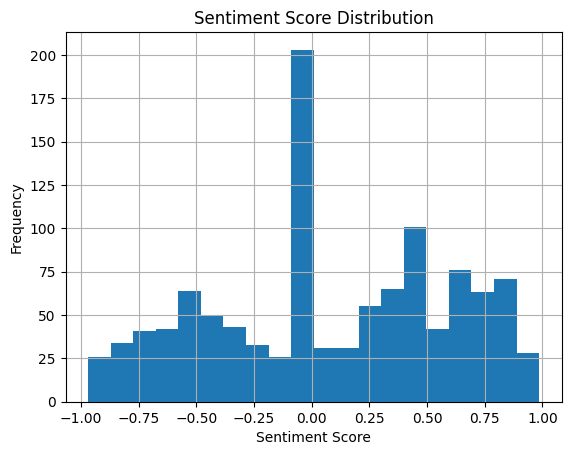

In [11]:
sia = SentimentIntensityAnalyzer()

dataset["sentiment"] = dataset["cleaned_post"].apply(lambda text: sia.polarity_scores(text)["compound"])

def lable(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

dataset["sentiment_label"] = dataset["sentiment"].apply(lable)

dataset["sentiment"].hist(bins=20)
plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

From this histogram of result values from the Vadar model, we can see that there is quite a lot of "netural" values and there is more "positive" values than "negative" values.

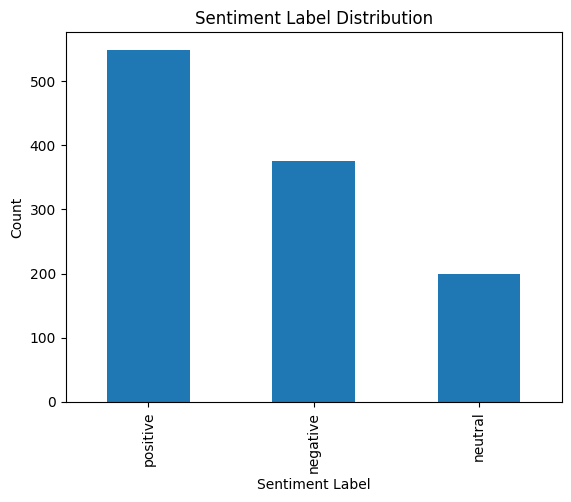

In [12]:
dataset["sentiment_label"].value_counts().plot(kind="bar")
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

The created bar chart confirms our findings from the histogram. This directly contradicts our hypothesis so we will attempt to confirm or deny these results using two different bert models. These will be Distilbert Base and Twitter Roberta Base.

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/home/tmd12/COSC3047-Assignment-2/.venv/lib/python3.12/site-packages/transformers/models/bert/tokenization_bert.py:104: DeprecationWarning: Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead
  self._tokenizer = Tokenizer(WordPiece(self._vocab, unk_token=str(unk_token)))


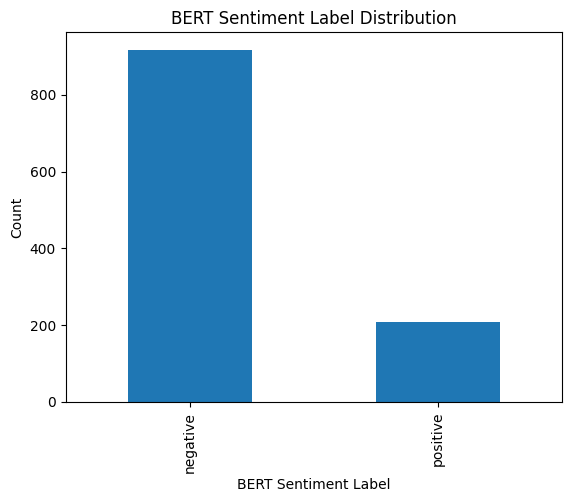

In [13]:
#bert_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
bert_sentiment = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
def get_bert_sentiment(text):
    result = bert_sentiment(text[:512])[0]
    return result["label"], result["score"]

dataset[["bert_label", "bert_score"]] = dataset["cleaned_post"].apply(lambda x: pd.Series(get_bert_sentiment(x)))

dataset['bert_label'] = dataset['bert_label'].str.lower()

dataset["bert_label"].value_counts().plot(kind="bar")
plt.title("BERT Sentiment Label Distribution")
plt.xlabel("BERT Sentiment Label")
plt.ylabel("Count")
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/tmd12/COSC3047-Assignment-2/.venv/lib/python3.12/site-packages/transformers/models/roberta/tokenization_roberta.py:144: DeprecationWarning: Deprecated in 0.9.0: BPE.__init__ will not create from files anymore, try `BPE.from_file` instead
  BPE(


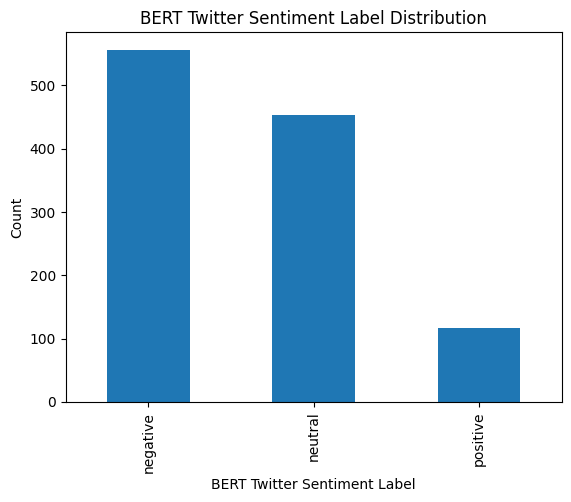

In [14]:
bert_sentiment1 = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")
def get_bert_sentiment1(text):
    result = bert_sentiment1(text[:512])[0]
    return result["label"], result["score"]

dataset[["bert_label1", "bert_score1"]] = dataset["cleaned_post"].apply(lambda x: pd.Series(get_bert_sentiment1(x)))
dataset['bert_label1'] = dataset['bert_label1'].str.lower()

dataset["bert_label1"].value_counts().plot(kind="bar")
plt.title("BERT Twitter Sentiment Label Distribution")
plt.xlabel("BERT Twitter Sentiment Label")
plt.ylabel("Count")
plt.show()

The results from both the Distilbert Base and the Twitter Roberta Base models clearly show that our inital assumption is correct unlike the Vadar model. This could be because of a number of factors but it is most likly due to the major difference in the models. Due to the correlation of results between Distilbert Base and Twitter Roberta Base, they are more likly to be correct for our dataset rather than the Vadar results and thus will be used to determine our final thoughts.

## Part 2.2: Topic Analysis

In [15]:
def display_topics(model, featureNames, numTopWords):
    # print out the topic distributions
    for topicId, lTopicDist in enumerate(model.components_):
        print("Topic %d:" % (topicId))
        print(" ".join([featureNames[i] for i in lTopicDist.argsort()[:-numTopWords - 1:-1]]))

In [16]:
def displayWordcloud(model, featureNames):
    # this normalises each row/topic to sum to one
    # use this normalisedComponents to display your wordclouds
    normalisedComponents = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    
    topicNum = len(model.components_)
    # number of wordclouds for each row
    plotColNum = 3
    # number of wordclouds for each column
    plotRowNum = int(math.ceil(topicNum / plotColNum))

    for topicId, lTopicDist in enumerate(normalisedComponents):
        lWordProb = {featureNames[i] : wordProb for i,wordProb in enumerate(lTopicDist)}
        wordcloud = WordCloud(background_color='black')
        wordcloud.fit_words(frequencies=lWordProb)
        plt.subplot(plotRowNum, plotColNum, topicId+1)
        plt.title('Topic %d:' % (topicId+1))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")

    plt.show(block=True)

In [ ]:
# LDA parameters

topicNum = 10

wordNumToDisplay = 15

featureNum = 1500

In [ ]:
# Count Vectorizer
tfVectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform(dataset["cleaned_post"])

tfFeatureNames = tfVectorizer.get_feature_names_out()

# LDA MODEL

ldaModel = LatentDirichletAllocation(n_components =topicNum, max_iter=10, learning_method='online').fit(tf)

In [19]:
display_topics(ldaModel, tfFeatureNames, wordNumToDisplay)

Topic 0:
lawyer legal client theyre website app available berkeley judge io author practice stance pure law
Topic 1:
ai game intelligence artificial slop shift video steam google company openai job use meta new
Topic 2:
ai game generative work slop come new read thing llm great pathfinding actually told year
Topic 3:
ai game got generative make model tool im kind write studio good calling month think
Topic 4:
case making ill resource music tool know agree check money whats devs community aigenerated material
Topic 5:
im machine learning hate youre phone bit job non worse bullshit impossible id shit yeah
Topic 6:
ai generative like people bad good game slop dont thing make art want using time
Topic 7:
ai game generative genai slop art tool video say year make development use idea creator
Topic 8:
ai game link new source far war artificial intelligence medium reason post robot newspaper create
Topic 9:
face best na thinking gon going good hey place loudly citation turn usage lmao eye


In [20]:
panel = pyLDAvis.lda_model.prepare(ldaModel, tf, tfVectorizer, mds='tsne')
pyLDAvis.display(panel)

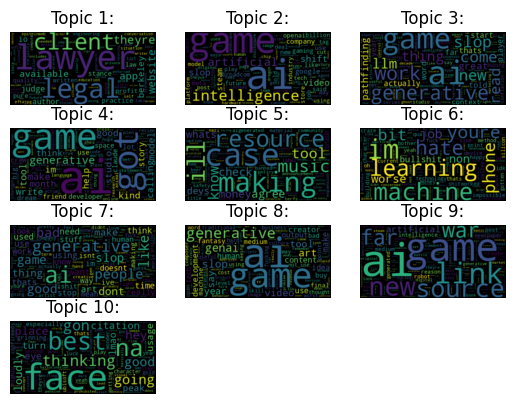

In [21]:
displayWordcloud(ldaModel, tfFeatureNames)